In [17]:
import datetime
import os
from time import strftime
import numpy as np
from datetime import timedelta
from itertools import product
from datetime import datetime
import shutil
import pyodbc
import pandas as pd
import pandasql as psql
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.regime_switching.markov_regression import MarkovRegression
import os
from IPython.display import display, HTML
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

user = os.getlogin()

## Serie

#### _Para la obtención de los datos se utilizaron los precios diarios de los granos publicados por el oce-wasde-report entre los años 2010-2020_

In [3]:
precios = pd.read_excel("C:\\Users\\"+ user +"\\OneDrive\\igor\\1. Posgrado\\2. Maestría - MEC\\3. Trabajo de grado\\1. Trabajo-Maestr-a-MEC\\1. Datos\\Precios agro.xlsx",
                        index_col="Unnamed: 0",
                        # parse_dates=True
                        )

commodities = ['Oilseed, Soybean','Corn','Wheat']

indicador1 = pd.read_excel("C:\\Users\\"+ user +"\\OneDrive\\igor\\1. Posgrado\\2. Maestría - MEC\\3. Trabajo de grado\\1. Trabajo-Maestr-a-MEC\\1. Datos\\oce-wasde-report-data-2016-01-to-2020-12.xlsx")
indicador = pd.read_excel("C:\\Users\\"+ user +"\\OneDrive\\igor\\1. Posgrado\\2. Maestría - MEC\\3. Trabajo de grado\\1. Trabajo-Maestr-a-MEC\\1. Datos\\oce-wasde-report-data-2010-04-to-2015-12.xlsx")

# 
indicador = pd.concat([indicador1, indicador], ignore_index=True)

indicador = indicador[(indicador["Commodity"].isin(list(commodities)))]

indicador_paises = indicador["Unit"].drop_duplicates()

indicador["ReleaseDate"] = indicador["ReleaseDate"].astype(str).str[:10]

### Consulta SQL estilo clásico

In [5]:
query = """
    SELECT 
    ReleaseDate,
    Attribute as consumo_total,
    Value,
    Commodity
    FROM indicador
    WHERE Attribute in ('Ending Stocks','Domestic Total') and
    Commodity in ('Oilseed, Soybean','Corn','Wheat') 
    and ProjEstFlag = 'Proj.' and Region = 'World'
    --ORDER BY ReleaseDate
    --GROUP BY Commodity_Description
"""

# Eiecutamos la consulta
resultado = psql.sqldf(query, locals())

# Exportar 
resultado.to_excel("C:\\Users\\"+ user +"\\OneDrive\\igor\\1. Posgrado\\2. Maestría - MEC\\3. Trabajo de grado\\1. Trabajo-Maestr-a-MEC\\1. Datos\\resultados.xlsx", index=False)

### Transformación de datos

##### Se agrega una nueva variable llamada stock/consumo el cual representa el ratio entre el stock mundial de granos y el consumo de los mismos, esta variable es usada por algunos investigadores del mercado de granos para explicar el posible incremento de los precios futuros.





In [7]:
# Tomar los datos de la carpeta Datos
# resultados = pd.read_excel("C:\\Users\\"+ user +"\\OneDrive\\igor\\1. Posgrado\\2. Maestría - MEC\\3. Trabajo de grado\\1. Trabajo-Maestr-a-MEC\\1. Datos\\resultados.xlsx")

# Tabla dinámica
pivot = pd.pivot_table(
    resultado,
    values="Value",       # qué valores vamos a resumir
    index="ReleaseDate",       # por qué agrupamos las filas
    columns=["consumo_total","Commodity"],         # qué va en las columnas
    aggfunc="sum",         # función de agregación (puede ser "sum", "count", "mean", etc.)
    fill_value=0           # para reemplazar NaN con 0
)

# Columnas nuevas
for i in ['Oilseed, Soybean','Corn','Wheat']:
    pivot.loc[:,("Stock/Consumo", i)] = pivot.loc[:,("Ending Stocks",i)]/pivot.loc[:,("Domestic Total",i)]

# 
pivot.index = pd.to_datetime(pivot.index)

precios.index = pd.to_datetime(precios.index,utc=True)

precios.index = pd.to_datetime(precios.index.astype(str).str[:10])

# materias primas
materias_primas = {"trigo":"Wheat",
            "soya":'Oilseed, Soybean',
            "maiz":'Corn'
            }
# Conjunto de datos de las materias primas
for i in materias_primas:
    a = pivot.loc[:,(pivot.columns.droplevel(1),materias_primas[i])]
    a.columns = [f"{a}" for a, b in a.columns]
    locals()[i] = pd.DataFrame(precios).merge(a,how= 'outer',left_index=True,right_index =True)

    # Primero asegurate de que la fecha sea índice datetime
    locals()[i].index = pd.to_datetime(locals()[i].index, dayfirst=True)
    
    # Ahora interpolar todas las columnas numéricas
    locals()[i] = locals()[i].interpolate(method='linear')
    
    # Eliminar los otros granos
    locals()[i].drop(columns=[x for x in list(materias_primas.keys()) if x != i],inplace =True)
    
    # Eliminar los vacíos
    locals()[i].dropna(inplace=True)

### Crear figura y eie principal

#### _Comparación de la nueva variable stock/consumo para cada una de los granos_

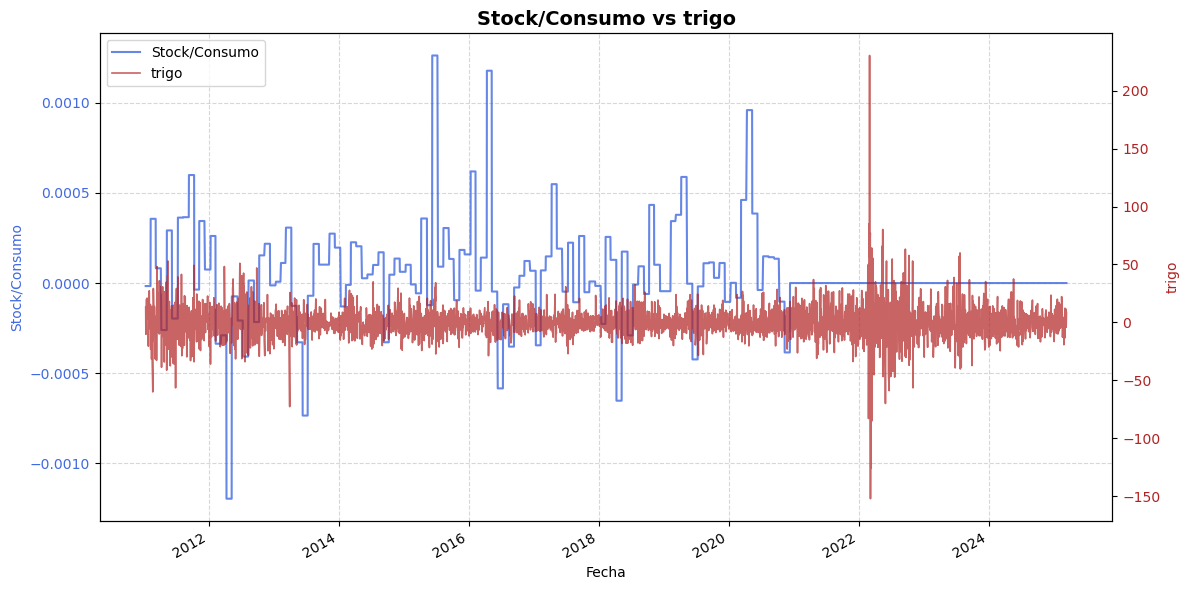

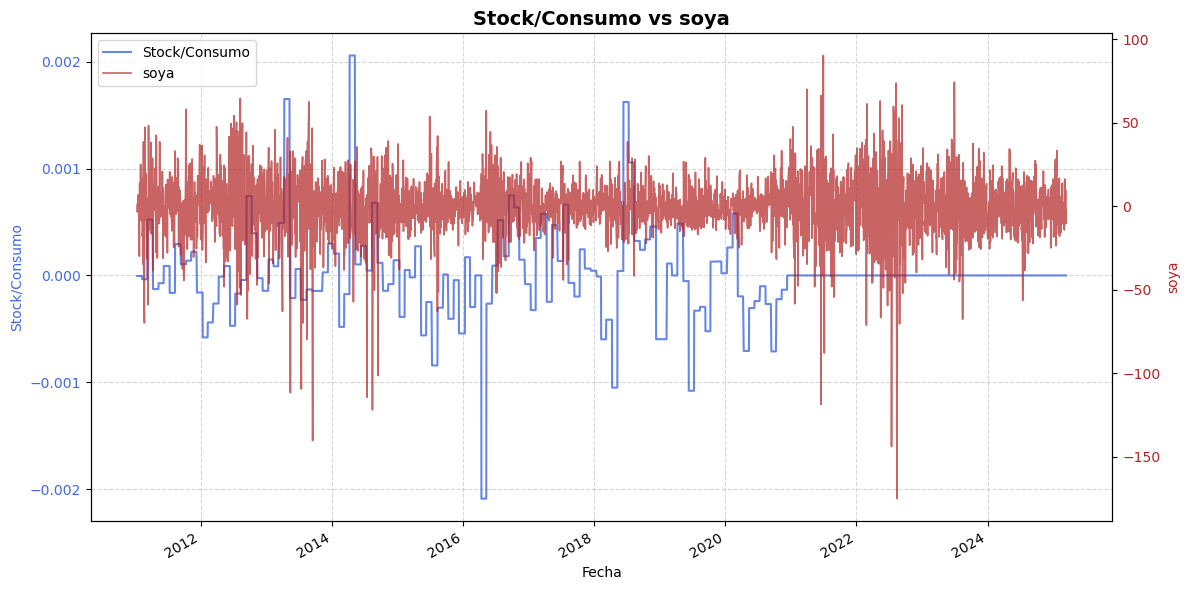

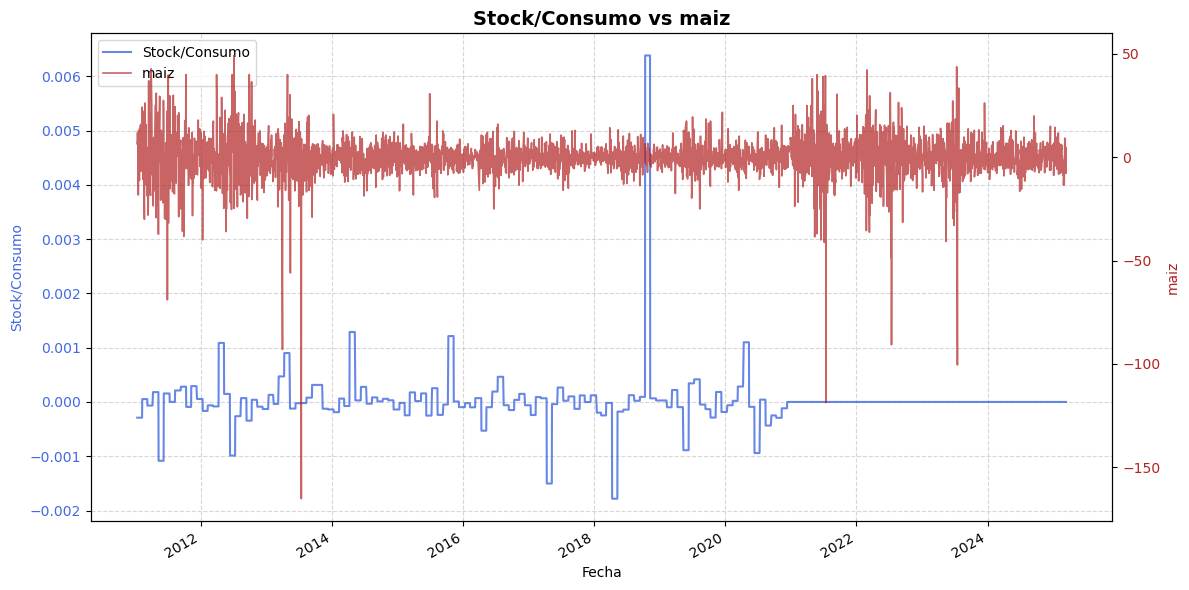

In [9]:
# For para la comparación de todos los granos y sus stock/consumo
for i in materias_primas.keys():
    fig, ax1 = plt.subplots(figsize=(12,6))  # tamaño más grande y cómodo
    
    # Serie Stock/Consumo
    ax1.plot(
        locals()[i].index, 
        locals()[i]["Stock/Consumo"].diff(),
        color="royalblue", linewidth=1.5, alpha=0.8, label="Stock/Consumo"
    )
    ax1.set_ylabel("Stock/Consumo", color="royalblue")
    ax1.tick_params(axis="y", labelcolor="royalblue")
    ax1.grid(True, linestyle="--", alpha=0.5)  # rejilla suave
    
    # Serie soya en eje derecho
    ax2 = ax1.twinx()
    ax2.plot(
        locals()[i].index, 
        locals()[i][i].diff(),
        color="firebrick", linewidth=1.2, alpha=0.7, label=i
    )
    ax2.set_ylabel(i, color="firebrick")
    ax2.tick_params(axis="y", labelcolor="firebrick")
    
    # Formato de eje X
    ax1.set_xlabel("Fecha")
    fig.autofmt_xdate()  # evita solapamiento de fechas
    
    # Leyenda combinada
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
    
    # Título
    plt.title(f"Stock/Consumo vs {i}", fontsize=14, fontweight="bold")
    
    plt.tight_layout()
    plt.show()


## Test de cointegración

### _Se le aplica un test de cointegración para saber si es posible aplicar un modelo VECM_

In [11]:
# In[Test de cointegracion

variables = {'soya':['Stock/Consumo','petroleo','diesel'], 
             'maiz':['Stock/Consumo','petroleo', 'engorde', 'diesel','gas_natural'],
             'trigo':['Stock/Consumo','petroleo', 'engorde', 'diesel','gas_natural']}


for i in materias_primas.keys():
    result = coint_johansen(locals()[i][variables[i]+[i]], det_order=0, k_ar_diff=1)
    
    # Mostrar los resultados
    resultados = pd.DataFrame({"Estadísticas de traza":result.lr1,
                  "Valores críticos (5%)":result.cvt[:, 1]})
    
    resultados["Decisión"] = resultados.iloc[:,0]>resultados.iloc[:,1]
    print(i)
    print(resultados)
    
    # Interpretación de cointegración
    num_cointegraciones = sum(result.lr1 > result.cvt[:, 1])
    print(f"👉 Número de relaciones de cointegración detectadas: {num_cointegraciones}")

trigo
   Estadísticas de traza  Valores críticos (5%)  Decisión
0             139.709923                95.7542      True
1              70.846310                69.8189      True
2              38.756988                47.8545     False
3              17.176366                29.7961     False
4               5.068598                15.4943     False
5               0.122179                 3.8415     False
👉 Número de relaciones de cointegración detectadas: 2
soya
   Estadísticas de traza  Valores críticos (5%)  Decisión
0              82.556249                47.8545      True
1              40.523758                29.7961      True
2              19.265590                15.4943      True
3               6.228406                 3.8415      True
👉 Número de relaciones de cointegración detectadas: 4
maiz
   Estadísticas de traza  Valores críticos (5%)  Decisión
0             123.857108                95.7542      True
1              59.024822                69.8189     False
2     

#### _Antes aplicar los modelos sobre los datos, se usa el modelo de switching para encontrar para cada una de las materias prima un régimen en el que los datos guarden dinámicas similares y así se pueda aplicar mejor la predicción_

                        Markov Switching Model Results                        
Dep. Variable:                  trigo   No. Observations:                 3697
Model:               MarkovRegression   Log Likelihood               -2985.906
Date:                Sun, 21 Sep 2025   AIC                           5983.812
Time:                        21:31:20   BIC                           6021.104
Sample:                    01-12-2011   HQIC                          5997.084
                         - 03-13-2025                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.7350      0.009    -83.171      0.000      -0.752      -0.718
sigma2         0.1320      0.004     29.678      0.0

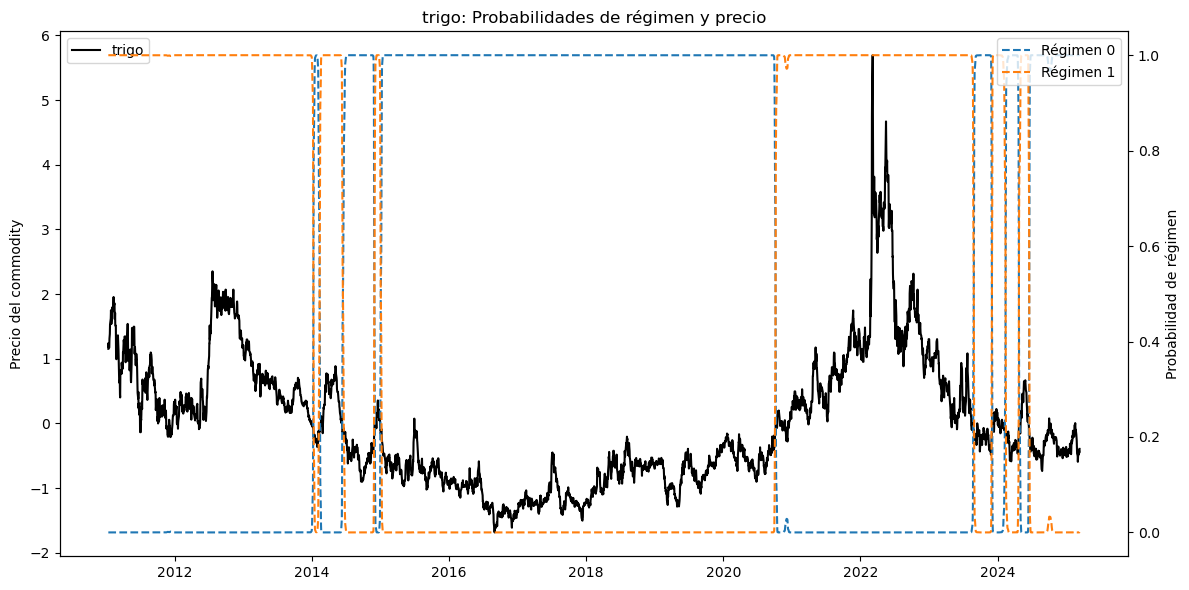

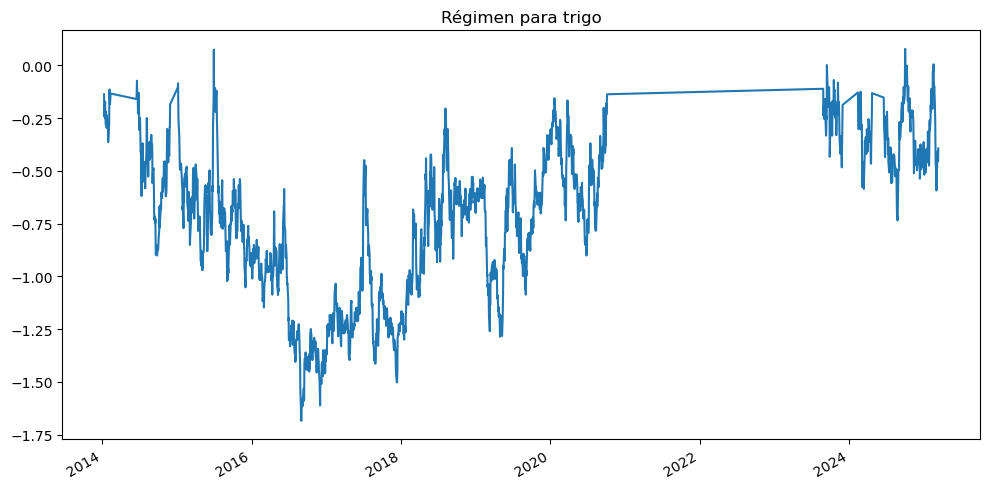

                        Markov Switching Model Results                        
Dep. Variable:                   soya   No. Observations:                 3697
Model:               MarkovRegression   Log Likelihood               -1939.233
Date:                Sun, 21 Sep 2025   AIC                           3890.465
Time:                        21:31:22   BIC                           3927.757
Sample:                    01-12-2011   HQIC                          3903.737
                         - 03-13-2025                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9287      0.007   -138.007      0.000      -0.942      -0.916
sigma2         0.0755      0.003     28.322      0.0

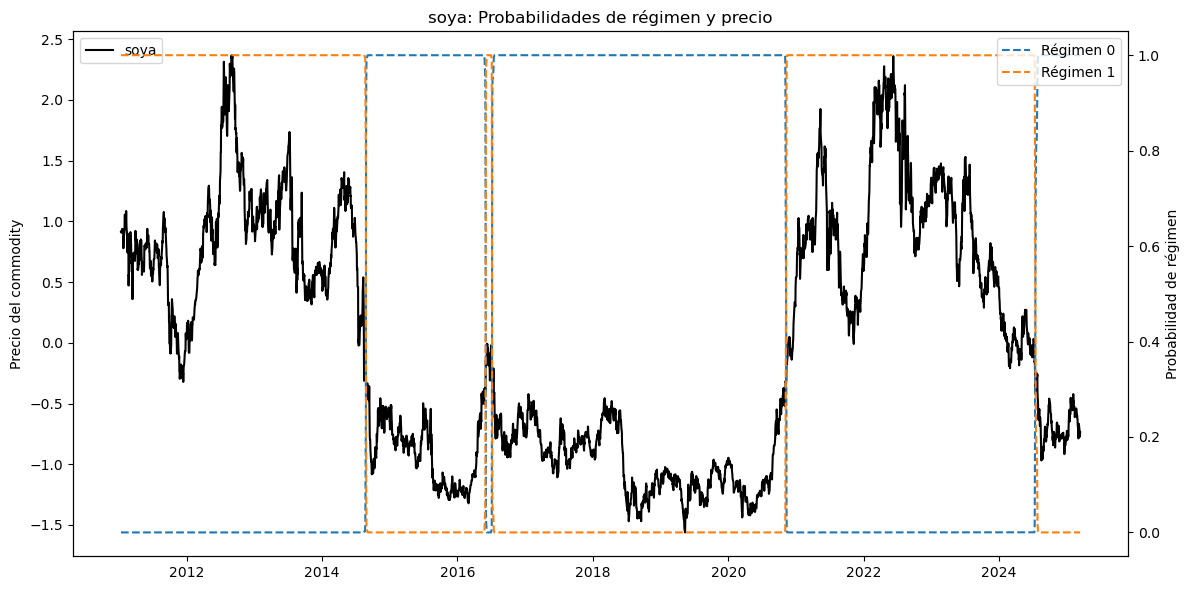

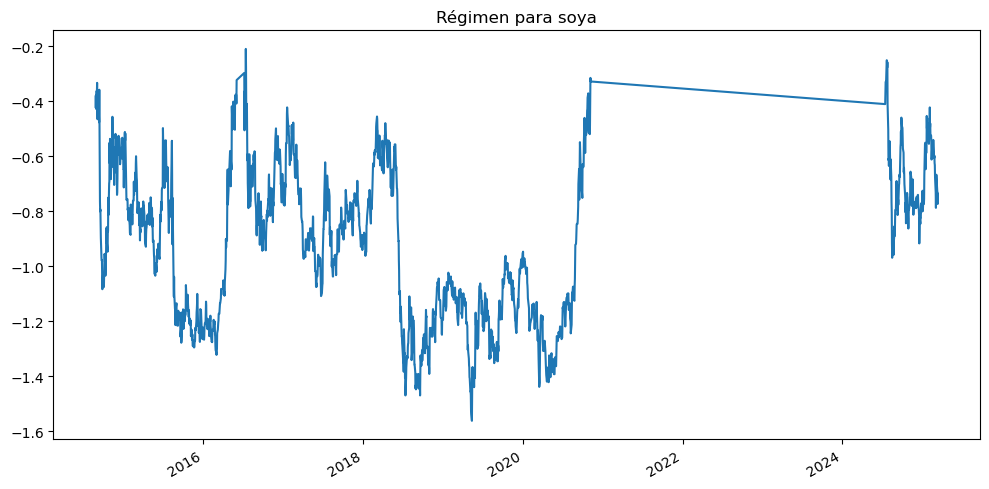

                        Markov Switching Model Results                        
Dep. Variable:                   maiz   No. Observations:                 3697
Model:               MarkovRegression   Log Likelihood               -1680.968
Date:                Sun, 21 Sep 2025   AIC                           3373.935
Time:                        21:31:24   BIC                           3411.227
Sample:                    01-12-2011   HQIC                          3387.207
                         - 03-13-2025                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.7654      0.006   -134.798      0.000      -0.776      -0.754
sigma2         0.0596      0.002     29.364      0.0

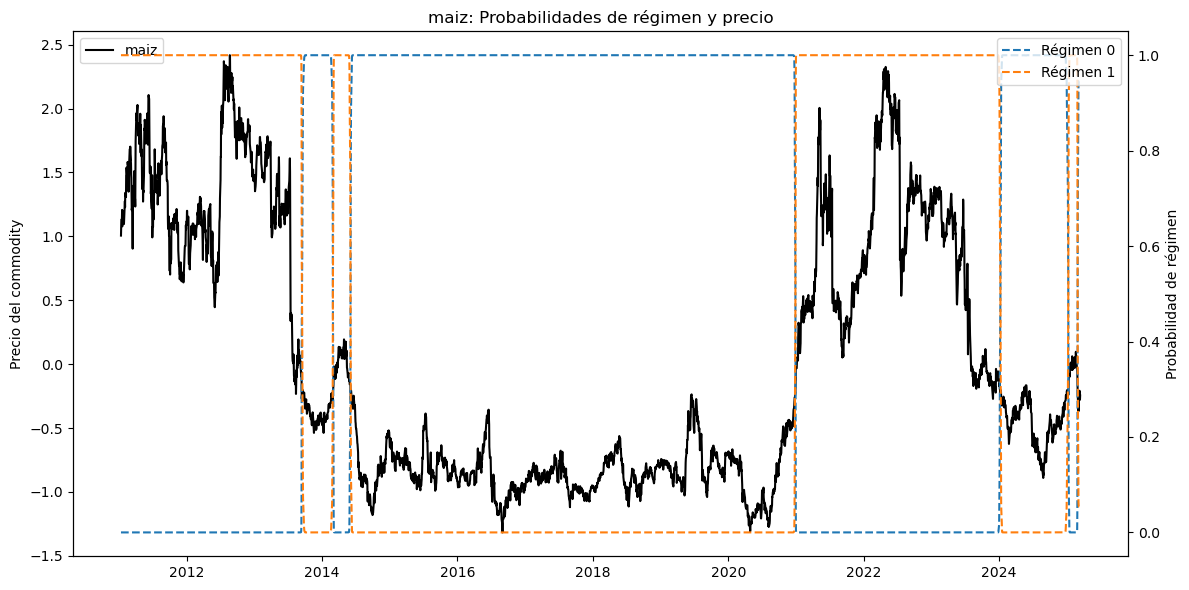

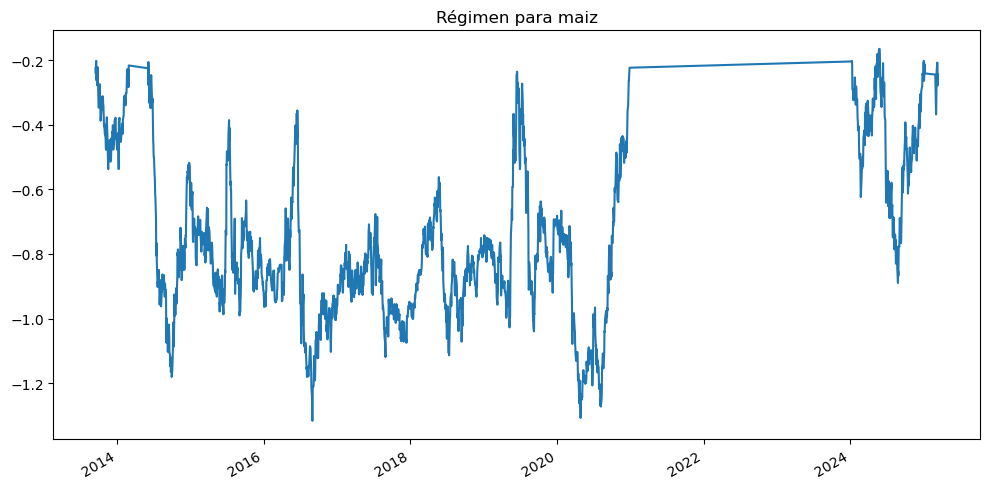

In [19]:
# In[Switching]

# commodities = ['maiz', 'trigo', 'soya']

regimenes = {}

# Modelo de switching para cada materia prima
for commodity in materias_primas.keys():
    
    # Se genera una variable y para cada una de las materias primas
    y = locals()[commodity][commodity]

    # Crear un rango de fechas continuo desde la primera hasta la última
    rango_fechas = pd.date_range(start=y.index.min(), end=y.index.max(), freq="B")
    
    # Reindexar el DataFrame a ese rango de días hábiles
    y = y.reindex(rango_fechas)
    
    # Rellenar los datos incompletos para poder tener una frecuencia marcada
    y.ffill(inplace = True) 

    # Transformar la serie en una serie normalizada, ya que para los datos en niveles no logra capturar los distintos regímenes
    y.iloc[:] = scaler.fit_transform(y.values.reshape(-1,1)).flatten()
    
    # Modelo de cambio de régimen con 2 regímenes y varianza cambiante
    model = sm.tsa.MarkovRegression(y, k_regimes=2, trend='c', switching_variance=True)
    result = model.fit()
    
    display(HTML(f"<h2>Resumen del modelo para {commodity}</h2>"))
    print(result.summary())
    
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    # Primer eje: Valores del commodity
    ax1.plot(y, label=commodity, color='black')
    ax1.set_ylabel('Precio del commodity')
    ax1.legend(loc='upper left')
        
    # Segundo eje: Probabilidades suavizadas  
    ax2 = ax1.twinx()
    ax2.plot(result.smoothed_marginal_probabilities[0], label='Régimen 0', linestyle='--')
    ax2.plot(result.smoothed_marginal_probabilities[1], label='Régimen 1', linestyle='--')
    # ax2.plot(result.smoothed_marginal_probabilities[2], label='Régimen 2', linestyle='--')
    # ax2.plot(result.smoothed_marginal_probabilities[3], label='Régimen 3', linestyle='--')
    ax2.set_ylabel('Probabilidad de régimen')
    ax2.set_title(f'{commodity}: Probabilidades de régimen y precio')
    ax2.legend(loc='upper right')
        
    plt.tight_layout()
    plt.show()
    
    # Guardar los regímenes
    locals()[commodity+"_regímenes"] = result.smoothed_marginal_probabilities.copy()
    # Encontrar el régimen dominante
    locals()[commodity+"_regímenes"]["Regimen_Dominante"] = locals()[commodity+"_regímenes"][list(locals()[commodity+"_regímenes"].columns)].idxmax(axis=1) #.str.extract('(\d)').astype(int)
    # desviacion
    regimenes[commodity] = {"Regimen 1":y.loc[locals()[commodity+"_regímenes"]["Regimen_Dominante"] == 0].std(),
                            "Regimen 2":y.loc[locals()[commodity+"_regímenes"]["Regimen_Dominante"] == 1].std()}
    # Filtrados
    locals()[commodity + "_filtrado_regimen"] = y.loc[locals()[commodity+"_regímenes"]["Regimen_Dominante"] == 0]
    
    # 
    locals()[commodity + "_filtrado_regimen"].plot(title=f"Régimen para " + commodity, figsize=(10, 5))
    plt.tight_layout()
    plt.show()
    

# Acumular los regimenes
std_regimen = pd.DataFrame.from_dict(regimenes, orient='index')

In [21]:
std_regimen

,Regimen 1,Regimen 2
trigo,0.362374,0.827168
soya,0.275419,0.577450
maiz,0.244843,0.668300


### Algunas conclusiones sobre el ejercicio de switching

#### _Luego de los resultados obtenidos del modelo de switching se puede evidenciar que existen regímenes distintos de volatilidad entre los años 2010 y 2024, donde para todos los granos, el período más estable fue entre los años 2014 y 2020. Debido a esto, se utilizará este período como caso de estudio el cuál representa un escenario de menor volatilidad_

## Exportar los frames para los modelos

In [62]:
with pd.ExcelWriter("C:\\Users\\"+ user +"\\OneDrive\\igor\\1. Posgrado\\2. Maestría - MEC\\3. Trabajo de grado\\1. Trabajo-Maestr-a-MEC\\1. Datos\\precios_filtrados_por_regimenes.xlsx", engine="openpyxl",  mode="w") as writer:
    soya.loc[soya_regímenes["Regimen_Dominante"] == 0].loc['2014':'2020',:].to_excel(writer, sheet_name="soya", index=True)
    maiz.loc[maiz_regímenes["Regimen_Dominante"] == 0].loc['2014':'2020',:].to_excel(writer, sheet_name="maiz", index=True)
    trigo.loc[trigo_regímenes["Regimen_Dominante"] == 0].loc['2014':'2020',:].to_excel(writer, sheet_name="trigo", index=True)

## Modelos VECM


#### _Una vez que se conoce que hay cointegración de los datos, es encontrado un régimen se  aplicar un modelo VEC_